This notebook goes through the basics of fitting in rayTEM. 

To begin, let's set up a simple set of lenses, and plot the result

In [ ]:
import sys
sys.path.insert(1,"../")
from pySEA.rayTEM.elements import Lens,Drift,fix_ray_dims,Source
from pySEA.rayTEM.assemblies import MicroscopeSection
from pySEA.rayTEM.postprocessing import fitForCrossover,plot2D
import numpy as np

def newSection(): # I am defining a function to generate a new Section each time, because later on, the fitting will edit Elements "in-place"
	elements=[ 	
		Source(size=(1,0),np_xy=(3,1),angle=(.5,0),na_xy=(3,1)),
		Drift(length=1),
		Lens(strength=3.8,length=.1), 
		Drift(length=3), 
		Lens(strength=4,length=.1), 
		Drift(length=3) ]
	return MicroscopeSection(elements=elements)

sec = newSection()
r = sec.propagate_ray()
plot2D(r, sec.R)


Image planes can be automagically detected by finding where rays emitted from the same point re-converge

Diffraction planes can be found by checking to see where two originally-parallel rays cross

Our basic plotting code automatically identified these planes, and the magnification for each. 

Fitting can thus be performed by perturbing strengths of elements (inside the "Element" object, inside the "Section" object), repropagating the rays, and iterating until, for example, a crossover is in the correct place or with the correct magnification. 

below, we will allow the strength of both lenses (element indices 2 and 4) to change, to attempt to find an image plane at z=6

ranges [[0.95, 7.6], [1.0, 8]]
(array([43]), array([41]))


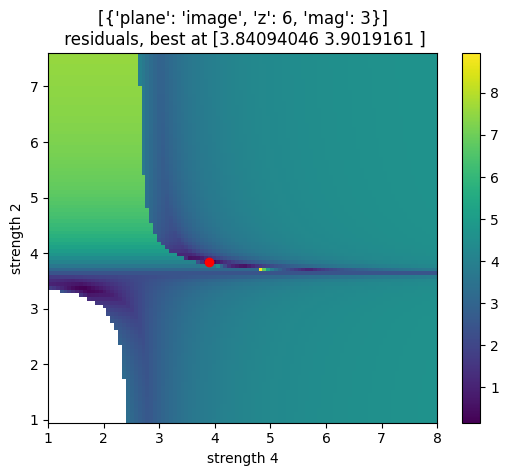

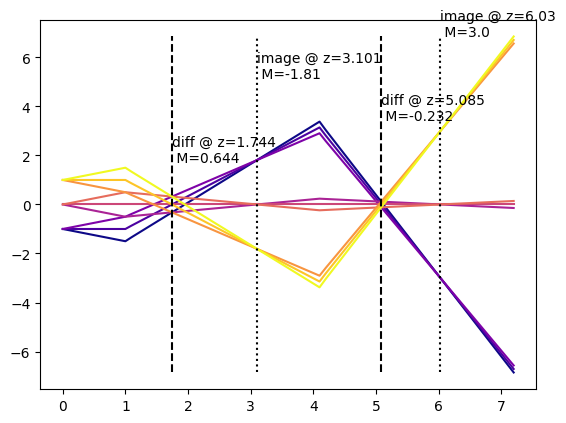

In [2]:
fitForCrossover(newSection(),targets=[{"plane":"image","z":6,"mag":3}],modifiable={2:"strength",4:"strength"})

The heatmap plot shows the "quality of fit" across the parameter space. the quality of fit is simply a metrix based on how close the image plane position and magnification are to what we specified, for each given pair of lens strengths. We see a couple "dark" regions indicating an image plane close to the correct location with nearly the correct magnification. There are multiple solutions to the problem, and there may be discontinuities in the parameter space, e.g. when changing a lens pushes an image plane "out of bounds" and we then need to shift the next image plane a great distance to compensate. 

Let's try to find other solutions. For example, it may be desirable to run lenses at lower currents (lower strength):

ranges [[0.95, 7.6], [1.0, 8]]
(array([36]), array([9]))


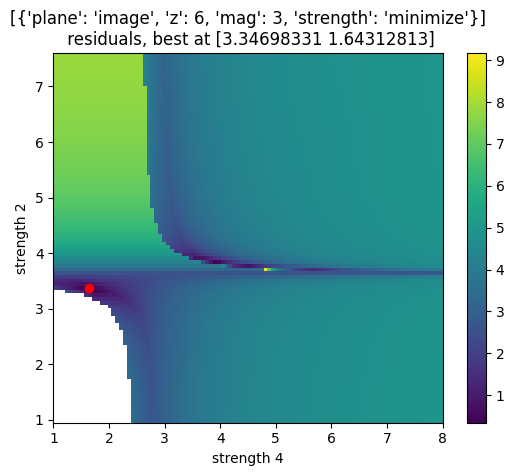

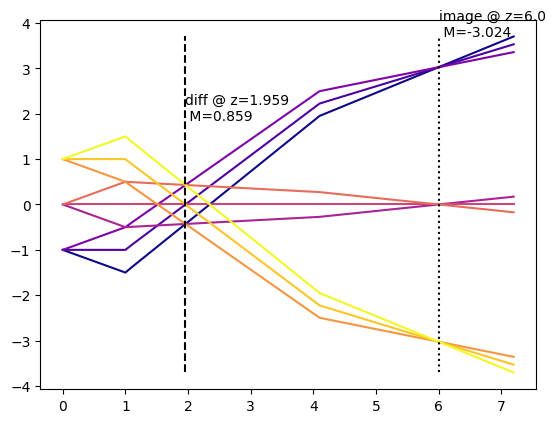

In [4]:
fitForCrossover(newSection(),targets=[{"plane":"image","z":6,"mag":3,"strength":"minimize"}],modifiable={2:"strength",4:"strength"})#,filename="figs/02_basicFitting_02")

Here, the metric for what counts as a good result is changed slightly. By including the lens strengths in metric we're trying to minimize, we can encourage the fitting algorithm to find the lower-current alternate solution. Here we see the "best fit" (red dot on the contour) is more towards the lower left corner (lower lens strengths) and the focusing of each lens is less abrupt (seen in the ray tracing diagram)